In [1]:
import os
import numpy as np
import tensorflow as tf
import keras
from keras import layers
from tensorflow import data as tf_data
import matplotlib.pyplot as plt

In [2]:
num_skipped = 0
for folder_name in ("Cat", "Dog"):
    folder_path = os.path.join("PetImages", folder_name)
    for fname in os.listdir(folder_path):
        fpath = os.path.join(folder_path, fname)
        try:
            fobj = open(fpath, "rb")
            is_jfif = b"JFIF" in fobj.peek(10)
        finally:
            fobj.close()
        
        if not is_jfif:
            num_skipped += 1
            # Delete corrupted image
            os.remove(fpath)

print(f"Deleted {num_skipped} images.")

Deleted 0 images.


In [3]:
image_size = (180, 180)
batch_size = 32

full_train_ds, full_val_ds = keras.utils.image_dataset_from_directory(
    "PetImages",
    validation_split=0.2,
    subset="both",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size,
    shuffle=True
)

# How large (%) is the subset 
subset_ratio = 1

num_train_batches = int(len(full_train_ds) * subset_ratio)
num_val_batches = int(len(full_val_ds) * subset_ratio)

train_ds = full_train_ds.take(num_train_batches)
val_ds = full_val_ds.take(num_val_batches)

Found 23410 files belonging to 2 classes.
Using 18728 files for training.
Using 4682 files for validation.


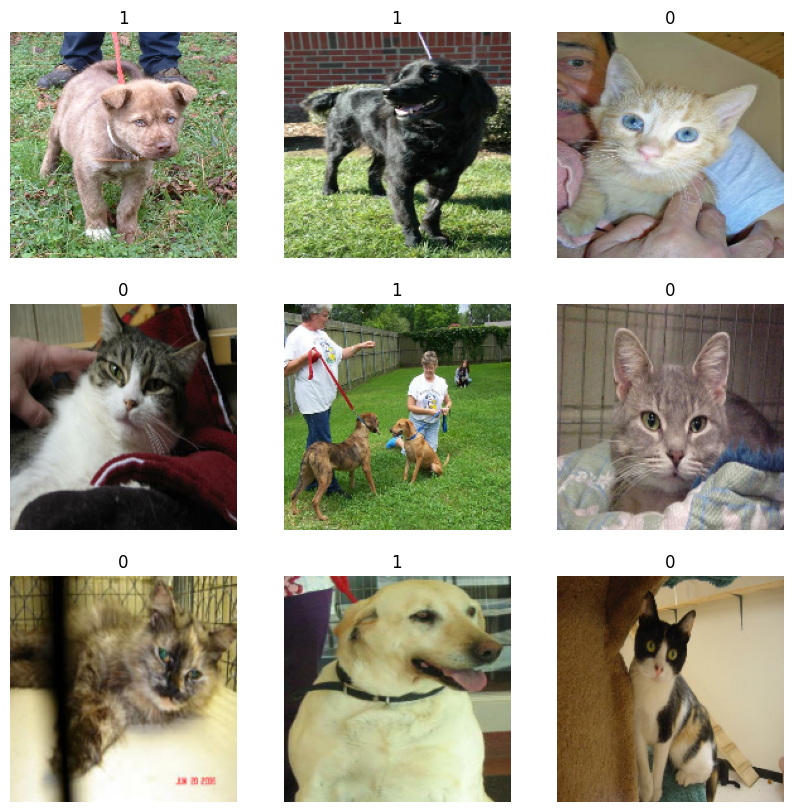

In [4]:
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(np.array(images[i]).astype("uint8"))
        plt.title(int(labels[i]))
        plt.axis("off")

In [5]:
data_augmentation_layers = [
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1)
]


def data_augmentation(images):
    for layer in data_augmentation_layers:
        images = layer(images)
    return images

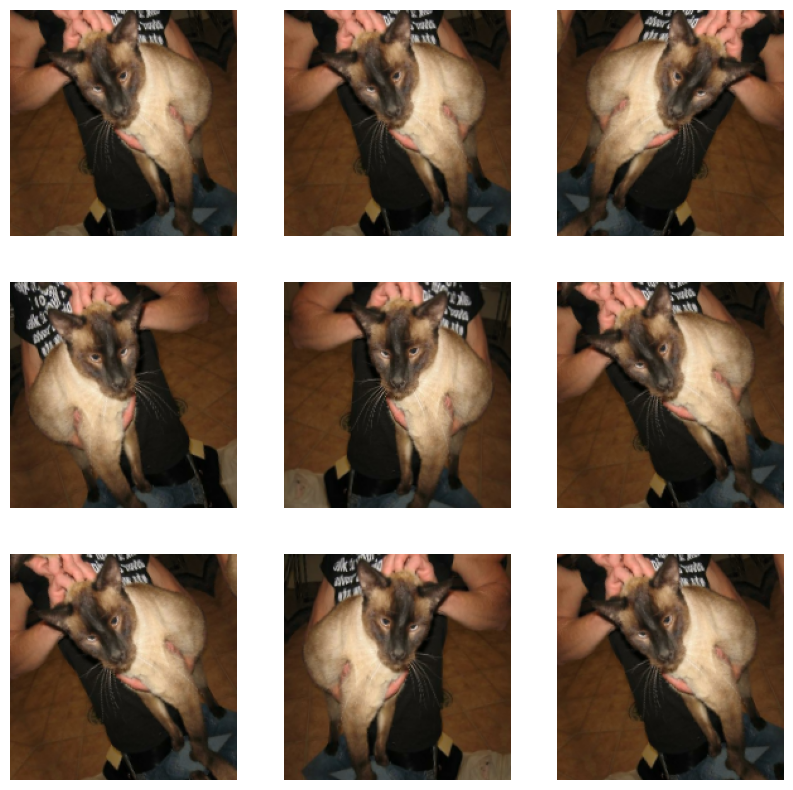

In [6]:
plt.figure(figsize=(10, 10))
for images, _ in train_ds.take(1):
    for i in range(9):
        augmented_images = data_augmentation(images)
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(np.array(augmented_images[0]).astype("uint8"))
        plt.axis("off")

In [7]:
augmented_train_ds = train_ds.map(lambda x, y: (data_augmentation(x), y))

In [8]:
train_ds = train_ds.map(
    lambda img, label: (data_augmentation(img), label),
    num_parallel_calls=tf_data.AUTOTUNE
)

train_ds = train_ds.prefetch(tf_data.AUTOTUNE)
val_ds = val_ds.prefetch(tf_data.AUTOTUNE)

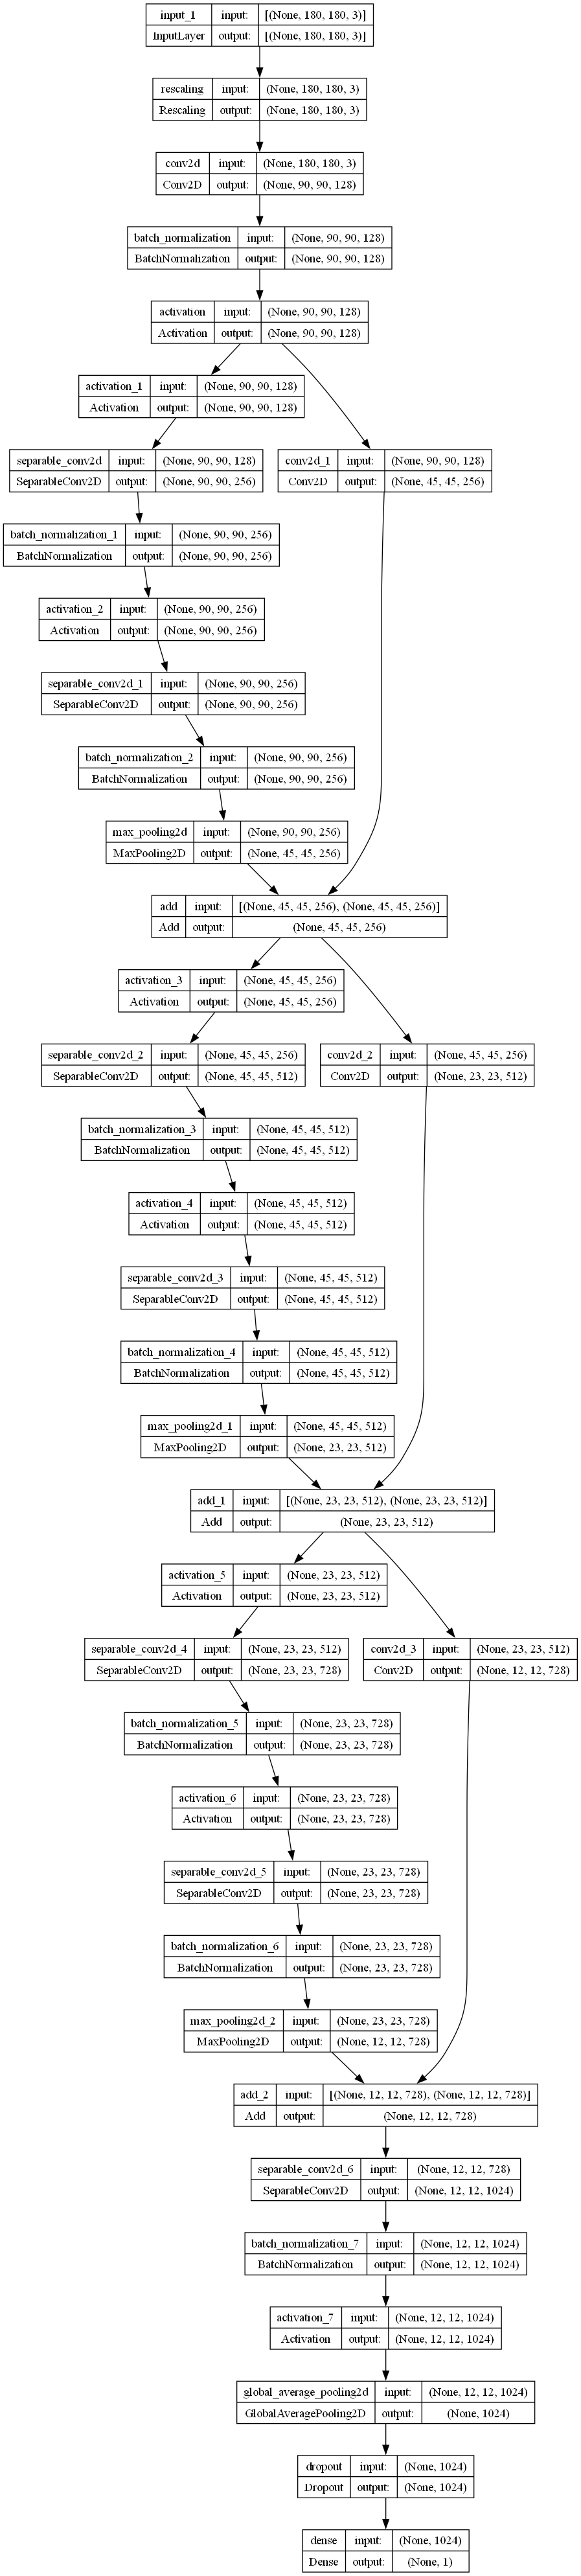

In [9]:
def make_model(input_shape, num_classes):
    inputs = keras.Input(shape=input_shape)

    # Entry block
    x = layers.Rescaling(1.0 / 255)(inputs)
    x = layers.Conv2D(128, 3, strides=2, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    previous_block_activation = x # Set aside residual

    for size in [256, 512, 728]:
        x = layers.Activation("relu")(x)
        x = layers.SeparableConv2D(size, 3, padding="same")(x)
        x = layers.BatchNormalization()(x)

        x = layers.Activation("relu")(x)
        x = layers.SeparableConv2D(size, 3, padding="same")(x)
        x = layers.BatchNormalization()(x)

        x = layers.MaxPooling2D(3, strides=2, padding="same")(x)

        residual = layers.Conv2D(size, 1, strides=2, padding="same")(
            previous_block_activation
        )
        x = layers.add([x, residual])
        previous_block_activation = x
    
    x = layers.SeparableConv2D(1024, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    x = layers.GlobalAveragePooling2D()(x)
    if num_classes == 2:
        units = 1
    else:
        units = num_classes

    x = layers.Dropout(0.25)(x)

    outputs = layers.Dense(units, activation=None)(x)
    return keras.Model(inputs, outputs)


model = make_model(input_shape=image_size + (3,), num_classes=2)
keras.utils.plot_model(model, show_shapes=True)

In [10]:
epochs = 25

callbacks = [
    keras.callbacks.ModelCheckpoint("save_at_{epoch}.keras")
]

model.compile(
    optimizer=keras.optimizers.Adam(0.0001),
    loss=keras.losses.BinaryCrossentropy(from_logits=True),
    metrics=[keras.metrics.BinaryAccuracy(name="acc")]
)

model.fit(
    train_ds,
    epochs=epochs,
    callbacks=callbacks,
    validation_data=val_ds
)

Epoch 1/25
586/586 [==============================] - 74s 114ms/step - loss: 0.5879 - acc: 0.6701 - val_loss: 0.8348 - val_acc: 0.4957
Epoch 2/25
586/586 [==============================] - 66s 113ms/step - loss: 0.4728 - acc: 0.7616 - val_loss: 0.4293 - val_acc: 0.8086
Epoch 3/25
586/586 [==============================] - 66s 113ms/step - loss: 0.3934 - acc: 0.8134 - val_loss: 0.6563 - val_acc: 0.7606
Epoch 4/25
586/586 [==============================] - 66s 113ms/step - loss: 0.3311 - acc: 0.8484 - val_loss: 0.3314 - val_acc: 0.8548
Epoch 5/25
586/586 [==============================] - 67s 114ms/step - loss: 0.2863 - acc: 0.8711 - val_loss: 0.3295 - val_acc: 0.8202
Epoch 6/25
586/586 [==============================] - 66s 113ms/step - loss: 0.2596 - acc: 0.8832 - val_loss: 0.2550 - val_acc: 0.8842
Epoch 7/25
586/586 [==============================] - 66s 113ms/step - loss: 0.2290 - acc: 0.9013 - val_loss: 0.3258 - val_acc: 0.8778
Epoch 8/25
586/586 [==============================] - 6

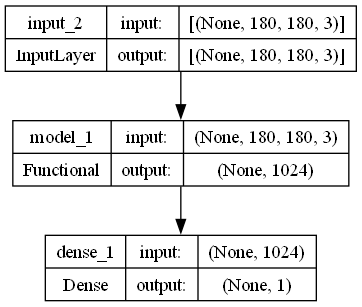

In [10]:
stanford_model = tf.keras.models.load_model("model.h5")

feature_extractor = keras.Model(
    inputs=stanford_model.input,
    outputs=stanford_model.layers[-2].output
)
feature_extractor.trainable = False

inputs = keras.Input(shape=image_size + (3,))
x = feature_extractor(inputs, training = False)
outputs = layers.Dense(1, activation=None)(x)

model = keras.Model(inputs, outputs)
keras.utils.plot_model(model, show_shapes=True)

In [19]:
epochs = 50

callbacks = [
    keras.callbacks.ModelCheckpoint("Experiment 2/save_at_{epoch}.keras")
]

model.compile(
    optimizer=keras.optimizers.Adam(0.0001),
    loss=keras.losses.BinaryCrossentropy(from_logits=True),
    metrics=[keras.metrics.BinaryAccuracy(name="acc")]
)

model.fit(
    train_ds,
    epochs=epochs,
    callbacks=callbacks,
    validation_data=val_ds
)

Epoch 1/50
586/586 [==============================] - 26s 34ms/step - loss: 0.6284 - acc: 0.6210 - val_loss: 0.5670 - val_acc: 0.7065
Epoch 2/50
586/586 [==============================] - 20s 34ms/step - loss: 0.5321 - acc: 0.7240 - val_loss: 0.5143 - val_acc: 0.7510
Epoch 3/50
586/586 [==============================] - 19s 33ms/step - loss: 0.4943 - acc: 0.7544 - val_loss: 0.4845 - val_acc: 0.7702
Epoch 4/50
586/586 [==============================] - 19s 32ms/step - loss: 0.4726 - acc: 0.7671 - val_loss: 0.4654 - val_acc: 0.7832
Epoch 5/50
586/586 [==============================] - 19s 33ms/step - loss: 0.4593 - acc: 0.7774 - val_loss: 0.4523 - val_acc: 0.7967
Epoch 6/50
586/586 [==============================] - 19s 32ms/step - loss: 0.4460 - acc: 0.7837 - val_loss: 0.4405 - val_acc: 0.7999
Epoch 7/50
586/586 [==============================] - 25s 43ms/step - loss: 0.4364 - acc: 0.7913 - val_loss: 0.4313 - val_acc: 0.8044
Epoch 8/50
586/586 [==============================] - 21s 35ms

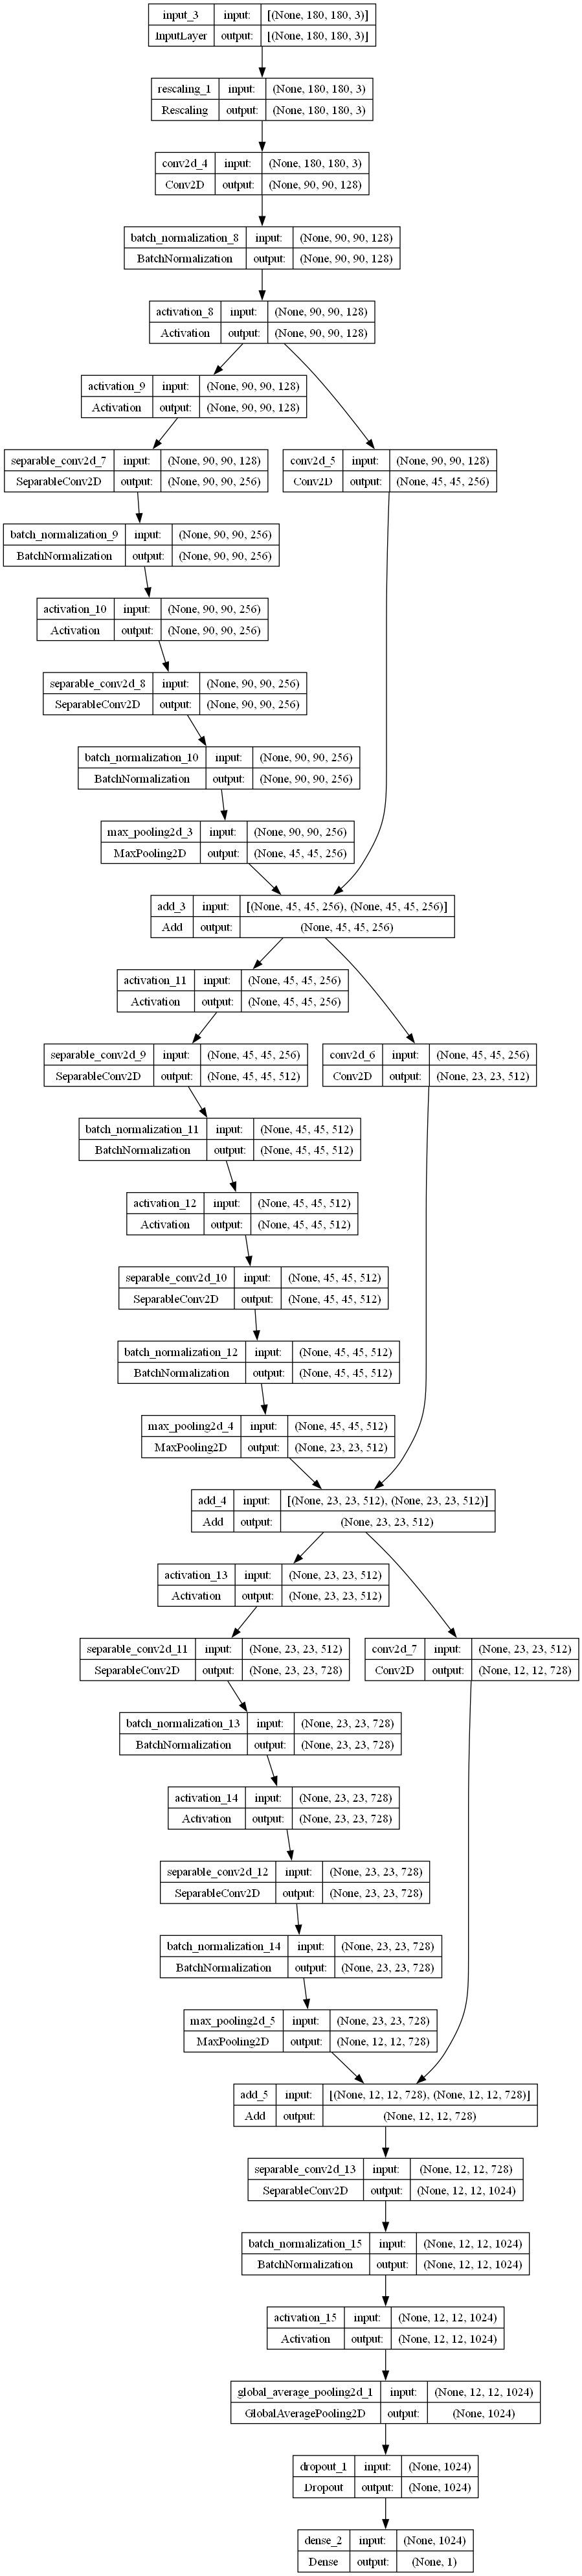

In [11]:
model = make_model(input_shape=image_size + (3,), num_classes=2)

replace_indices = [2, 6]

for i, (stanford_layer, new_layer) in enumerate(zip(stanford_model.layers, model.layers)):
    if i in replace_indices:
        continue
    if i == len(stanford_model.layers) - 1:
        continue

    new_layer.set_weights(stanford_layer.get_weights())

for layer in model.layers:
    layer.trainable = False

for i in replace_indices:
    model.layers[i].trainable = True

model.layers[-1].trainable = True
keras.utils.plot_model(model, show_shapes=True)

In [20]:
epochs = 50

callbacks = [
    keras.callbacks.ModelCheckpoint("Experiment 3/save_at_{epoch}.keras")
]

model.compile(
    optimizer=keras.optimizers.Adam(0.0001),
    loss=keras.losses.BinaryCrossentropy(from_logits=True),
    metrics=[keras.metrics.BinaryAccuracy(name="acc")]
)

model.fit(
    train_ds,
    epochs=epochs,
    callbacks=callbacks,
    validation_data=val_ds
)

Epoch 1/50
586/586 [==============================] - 52s 77ms/step - loss: 0.8290 - acc: 0.5670 - val_loss: 0.6221 - val_acc: 0.6277
Epoch 2/50
586/586 [==============================] - 46s 79ms/step - loss: 0.6575 - acc: 0.6110 - val_loss: 0.6071 - val_acc: 0.6134
Epoch 3/50
586/586 [==============================] - 45s 77ms/step - loss: 0.6310 - acc: 0.6267 - val_loss: 0.5832 - val_acc: 0.6736
Epoch 4/50
586/586 [==============================] - 48s 82ms/step - loss: 0.6127 - acc: 0.6408 - val_loss: 0.5738 - val_acc: 0.7095
Epoch 5/50
586/586 [==============================] - 47s 80ms/step - loss: 0.5974 - acc: 0.6600 - val_loss: 0.5534 - val_acc: 0.6899
Epoch 6/50
586/586 [==============================] - 47s 80ms/step - loss: 0.5819 - acc: 0.6693 - val_loss: 0.5383 - val_acc: 0.6991
Epoch 7/50
586/586 [==============================] - 47s 80ms/step - loss: 0.5688 - acc: 0.6848 - val_loss: 0.5474 - val_acc: 0.6628
Epoch 8/50
586/586 [==============================] - 49s 82ms

In [12]:
stanford_model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 180, 180, 3  0           []                               
                                )]                                                                
                                                                                                  
 rescaling (Rescaling)          (None, 180, 180, 3)  0           ['input_1[0][0]']                
                                                                                                  
 conv2d (Conv2D)                (None, 90, 90, 128)  3584        ['rescaling[0][0]']              
                                                                                                  
 batch_normalization (BatchNorm  (None, 90, 90, 128)  512        ['conv2d[0][0]']             

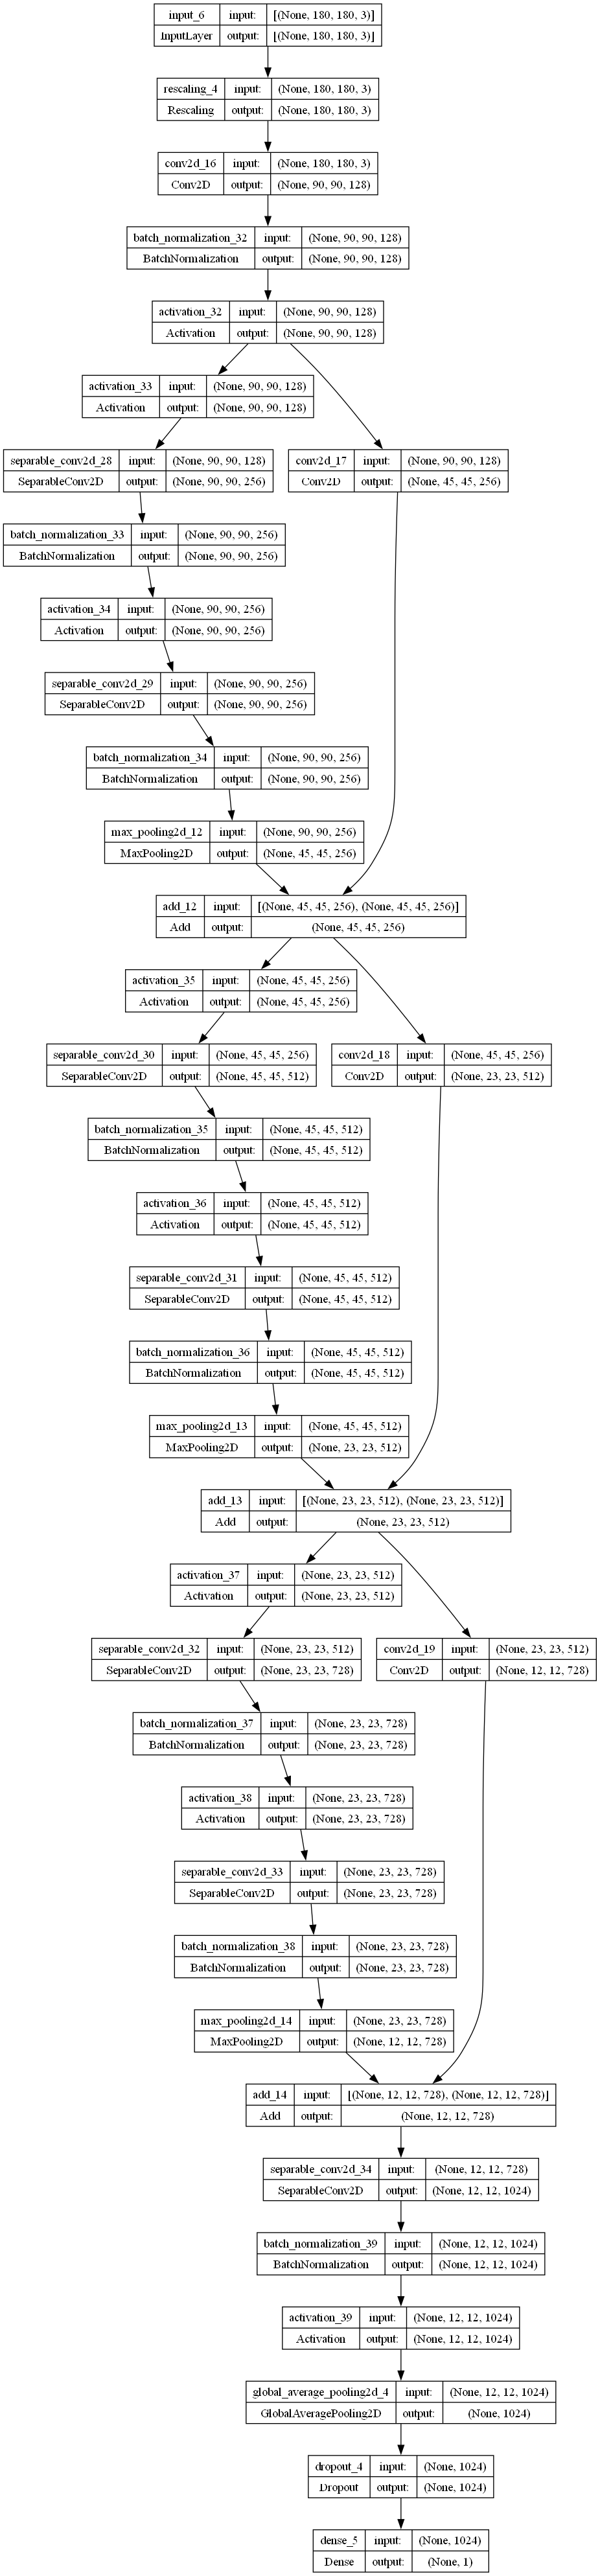

In [15]:
model = make_model(input_shape=image_size + (3,), num_classes=2)

replace_indices = [30, 32]

for i, (stanford_layer, new_layer) in enumerate(zip(stanford_model.layers, model.layers)):
    if i in replace_indices:
        continue
    if i == len(stanford_model.layers) - 1:
        continue

    new_layer.set_weights(stanford_layer.get_weights())

for layer in model.layers:
    layer.trainable = False

for i in replace_indices:
    model.layers[i].trainable = True

model.layers[-1].trainable = True
keras.utils.plot_model(model, show_shapes=True)

In [16]:
epochs = 50

callbacks = [
    keras.callbacks.ModelCheckpoint("Experiment 4/save_at_{epoch}.keras")
]

model.compile(
    optimizer=keras.optimizers.Adam(0.0001),
    loss=keras.losses.BinaryCrossentropy(from_logits=True),
    metrics=[keras.metrics.BinaryAccuracy(name="acc")]
)

model.fit(
    train_ds,
    epochs=epochs,
    callbacks=callbacks,
    validation_data=val_ds
)

Epoch 1/50
586/586 [==============================] - 25s 37ms/step - loss: 0.4773 - acc: 0.7515 - val_loss: 0.3563 - val_acc: 0.8321
Epoch 2/50
586/586 [==============================] - 21s 35ms/step - loss: 0.3511 - acc: 0.8373 - val_loss: 0.3073 - val_acc: 0.8689
Epoch 3/50
586/586 [==============================] - 20s 35ms/step - loss: 0.3149 - acc: 0.8572 - val_loss: 0.2830 - val_acc: 0.8832
Epoch 4/50
586/586 [==============================] - 20s 35ms/step - loss: 0.2903 - acc: 0.8700 - val_loss: 0.2677 - val_acc: 0.8742
Epoch 5/50
586/586 [==============================] - 21s 35ms/step - loss: 0.2797 - acc: 0.8747 - val_loss: 0.2496 - val_acc: 0.8906
Epoch 6/50
586/586 [==============================] - 21s 35ms/step - loss: 0.2605 - acc: 0.8845 - val_loss: 0.2632 - val_acc: 0.9035
Epoch 7/50
586/586 [==============================] - 21s 35ms/step - loss: 0.2467 - acc: 0.8892 - val_loss: 0.2395 - val_acc: 0.8823
Epoch 8/50
586/586 [==============================] - 21s 35ms